In [73]:
from utils.data import DataManager
from utils import preprocess
import pandas as pd
import importlib

importlib.reload(preprocess)

data_manager = DataManager()
data_manager.preparar_conjuntos()

X_train, y_train, weights_train = data_manager.get_train_data()
X_val, y_val, weights_val = data_manager.get_test_data()

test = data_manager.get_test()
weights = data_manager.get_weights()

X, y = data_manager.get_X_y()

data_preprocessor = preprocess.DataPreprocessor()

X_train = data_preprocessor.fit_transform(X_train)
X_val = data_preprocessor.transform(X_val)

transf_test = data_preprocessor.transform(test)
X = data_preprocessor.transform(X)

In [74]:
import tensorflow as tf
import keras_tuner as kt

norm_layer = tf.keras.layers.Normalization()
norm_layer.adapt(X_train)

In [76]:
def build_best_model():
    learning_rate = 0.0016478705

    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(X_train.shape[1],)))
    model.add(norm_layer)
    model.add(tf.keras.layers.Dense(60, activation="relu", kernel_initializer="he_normal"))
    model.add(tf.keras.layers.Dense(33, activation="relu", kernel_initializer="he_normal"))
    model.add(tf.keras.layers.Dense(53, activation="relu", kernel_initializer="he_normal"))
    model.add(tf.keras.layers.Dense(64, activation="relu", kernel_initializer="he_normal"))
    model.add(tf.keras.layers.Dense(42, activation="relu", kernel_initializer="he_normal"))
    model.add(tf.keras.layers.Dense(1, activation="sigmoid"))
              
    model.compile(loss="binary_crossentropy", optimizer=tf.keras.optimizers.Nadam(learning_rate=learning_rate),
              weighted_metrics=[])
              
    return model

In [77]:
best_model = build_best_model()

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    verbose=1,
    restore_best_weights=True
)

history = best_model.fit(
    X_train, y_train, 
    sample_weight=weights_train, 
    epochs=100,
    verbose=1, 
    callbacks=[early_stopping],
    validation_data=(X_val, y_val, weights_val)
)

Epoch 1/100
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 6s 724us/step - loss: 0.0416 - val_loss: 0.0158
Epoch 2/100
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 710us/step - loss: 0.0157 - val_loss: 0.0153
Epoch 3/100
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 5s 736us/step - loss: 0.0156 - val_loss: 0.0153
Epoch 4/100
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 5s 723us/step - loss: 0.0154 - val_loss: 0.0154
Epoch 5/100
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 5s 718us/step - loss: 0.0153 - val_loss: 0.0153
Epoch 6/100
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 716us/step - loss: 0.0152 - val_loss: 0.0154
Epoch 7/100
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 707us/step - loss: 0.0152 - val_loss: 0.0157
Epoch 8/100
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 700us/step - loss: 0.0152 - val_loss: 0.0152
Epoch 9/100
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 5s 718us/step - loss: 0.0153 - val_loss: 0.0153
Epoch 10/100
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 704us/step - loss: 0.0151 - val_loss: 0.0182
Epoch 11/100
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 704us/step - loss: 0.0151 - val_loss: 0.01

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 444us/step
[ 0.00000000e+00  4.36802386e-04  4.80482625e-04 ... -5.52506942e-06
  1.37563739e-05  0.00000000e+00]


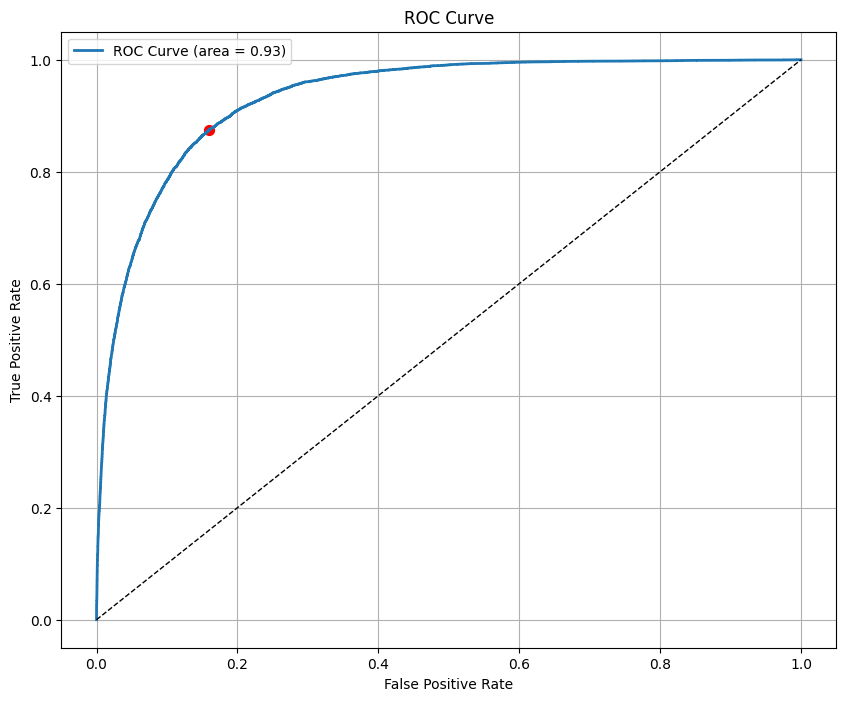

Best Threshold: 0.001753331


In [26]:
from sklearn.metrics import auc
from sklearn.model_selection import cross_val_predict
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
import numpy as np
from sklearn.metrics import roc_auc_score

y_scores = np.array(best_model.predict(X_val)).flatten()
fpr, tpr, thresholds_auc = roc_curve(y_val, y_scores, sample_weight=weights_val)

J = tpr - fpr
print(J)
idx = np.argmax(J)

auc = roc_auc_score(y_val, y_scores, sample_weight=weights_val)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, label=f'ROC Curve (area = {auc:.2f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.scatter(fpr[idx], tpr[idx], c='red', s=50)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

best_thresh = thresholds_auc[idx]
print("Best Threshold:", best_thresh)


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 439us/step


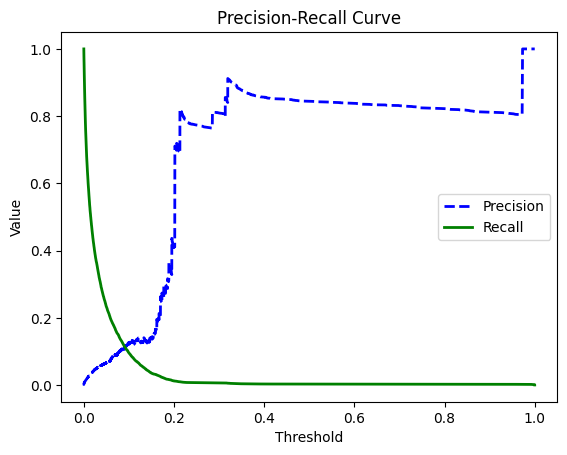

In [27]:
from utils.metrics import MetricsManager
import utils.metrics as m
from importlib import reload
reload(m)
import numpy as np

y_pred_proba = np.array(best_model.predict(X_val)).flatten()
y_true = y_val

MetricsManager.plot_precision_recall_vs_threshold(y_true, y_pred_proba, sample_weight=weights_val)


In [28]:
from sklearn.metrics import precision_recall_curve
import importlib
import utils.HiggsBosonCompetition_AMSMetric_rev1 as hb_metrics

importlib.reload(hb_metrics)

y_test_scores = best_model.predict(X_val)
precision, recall, thresholds = precision_recall_curve(y_val, y_test_scores, sample_weight=weights_val)

best_ams = 0
best_threshold = 1

ams_scores = []
threshold_values = []

for i in range(len(thresholds)):
    y_pred = (y_test_scores >= thresholds[i]).astype(int)
    y_pred = y_pred.flatten()
    ams = hb_metrics.ams_scorer(y_val, y_pred, weights_val)

    ams_scores.append(ams)
    threshold_values.append(thresholds[i])

    if ams > best_ams:
        best_ams = ams
        best_threshold = thresholds[i]



1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 446us/step


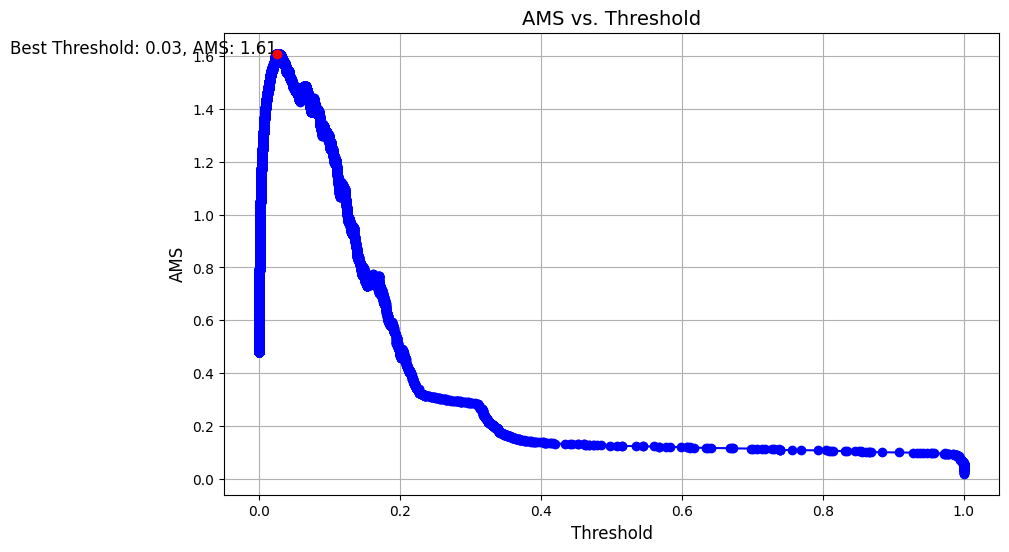

In [36]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))
plt.plot(threshold_values, ams_scores, marker='o', linestyle='-', color='b')

best_idx = np.argmax(ams_scores)
best_threshold = threshold_values[best_idx]
best_ams = ams_scores[best_idx]
plt.scatter([best_threshold], [best_ams], color='red', zorder=5)
plt.text(best_threshold, best_ams, f'Best Threshold: {best_threshold:.2f}, AMS: {best_ams:.2f}',
         fontsize=12, ha='right')

plt.title('AMS vs. Threshold', fontsize=14)
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('AMS', fontsize=12)
plt.grid(True)
plt.show()


In [37]:
print(f"Best Threshold: {best_threshold}, Best AMS: {best_ams}")

Best Threshold: 0.025001192465424538, Best AMS: 1.6087805776465258


In [38]:
best_model.save('final_model.keras')
best_thresh = 0.31

In [39]:
y_test_scores = best_model.predict(transf_test)
y_test_pred = (y_test_scores >= best_threshold).astype(int)
y_test_scores = y_test_scores.flatten()
y_test_pred = y_test_pred.flatten()

submission_df = pd.DataFrame({
    "EventId": test["EventId"],
    "Class": y_test_pred,
    "Probability": y_test_scores
})

submission_df = submission_df.sort_values(by='Probability', ascending=False)
submission_df['RankOrder'] = range(1, len(submission_df) + 1)
submission_df['Class'] = submission_df['Class'].map({1: 's', 0: 'b'})
submission_df = submission_df[['EventId', 'Class', 'RankOrder']]
submission_df.to_csv("submission.csv", index=False)

17188/17188 ━━━━━━━━━━━━━━━━━━━━ 7s 419us/step


In [41]:
!kaggle competitions submit -c taa-2024-desafo-bosn-de-higgs -f submission.csv -m "Final model submission"

Successfully submitted to TAA 2024 - Desafío Bosón de Higgs



  0%|          | 0.00/8.81M [00:00<?, ?B/s]
  1%|          | 96.0k/8.81M [00:00<00:09, 980kB/s]
 10%|▉         | 880k/8.81M [00:00<00:01, 5.07MB/s]
 15%|█▌        | 1.34M/8.81M [00:00<00:01, 4.43MB/s]
 25%|██▌       | 2.22M/8.81M [00:00<00:01, 6.15MB/s]
 32%|███▏      | 2.83M/8.81M [00:00<00:01, 3.22MB/s]
 37%|███▋      | 3.28M/8.81M [00:01<00:02, 2.82MB/s]
 41%|████▏     | 3.65M/8.81M [00:01<00:01, 3.01MB/s]
 46%|████▌     | 4.02M/8.81M [00:01<00:01, 3.15MB/s]
 50%|████▉     | 4.38M/8.81M [00:01<00:01, 3.31MB/s]
 54%|█████▍    | 4.75M/8.81M [00:01<00:01, 3.41MB/s]
 58%|█████▊    | 5.12M/8.81M [00:01<00:01, 3.52MB/s]
 62%|██████▏   | 5.48M/8.81M [00:01<00:00, 3.59MB/s]
 66%|██████▋   | 5.85M/8.81M [00:01<00:00, 3.62MB/s]
 70%|███████   | 6.21M/8.81M [00:01<00:00, 3.62MB/s]
 75%|███████▍  | 6.57M/8.81M [00:01<00:00, 3.65MB/s]
 79%|███████▊  | 6.93M/8.81M [00:02<00:00, 3.62MB/s]
 83%|████████▎ | 7.29M/8.81M [00:02<00:00, 3.64MB/s]
 87%|████████▋ | 7.64M/8.81M [00:02<00:00, 3.59MB/s]
 91

In [ ]:
from utils.comet_experiments import exp_eval_nn
exp_eval_nn("Red neuronal final", best_model, X_val, y_val, weights_val, "tZzHrgZeB2lMeZSSnDvSFUAIV")

In [79]:
import shap
import numpy as np

X1000 = shap.kmeans(X_train, 1000)
X_val = X_val[:100]
explainer = shap.KernelExplainer(best_model.predict, X1000.data)


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


Using 1000 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/100 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1s 381us/step


  1%|          | 1/100 [00:02<03:36,  2.19s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1s 381us/step


  2%|▏         | 2/100 [00:05<04:38,  2.84s/it]

...

 98%|█████████▊| 98/100 [04:05<00:05,  2.64s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 2s 484us/step


 99%|█████████▉| 99/100 [04:08<00:02,  2.64s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1s 476us/step


100%|██████████| 100/100 [04:11<00:00,  2.51s/it]


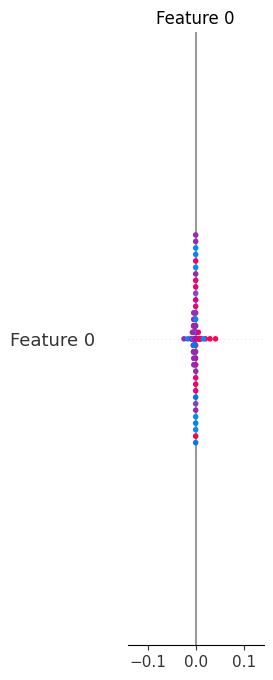

In [80]:
shap_values = explainer.shap_values(X_val, nsamples=100)
shap.summary_plot(shap_values, X_val)

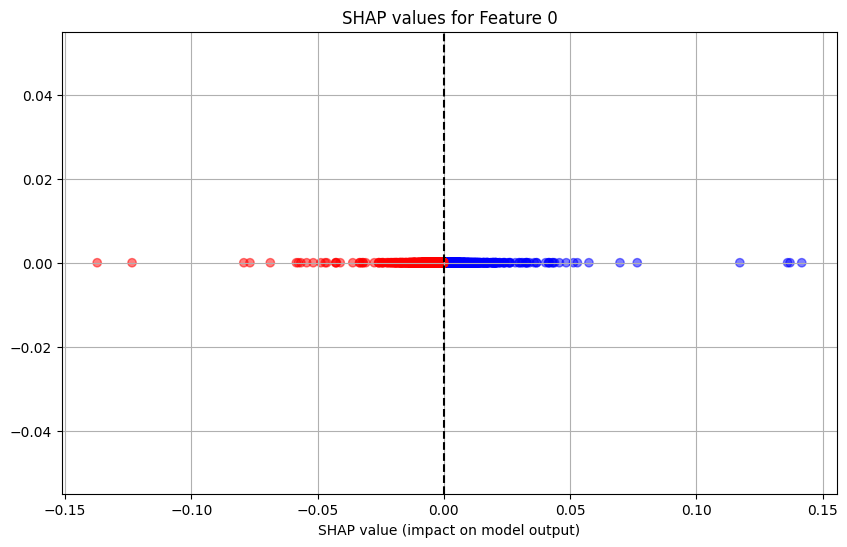

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
for i in range(len(shap_values)):
    plt.scatter(shap_values[i], [0] * len(shap_values[i]), c=['b' if x > 0 else 'r' for x in shap_values[i]], alpha=0.5, edgecolor=None)
plt.title("SHAP values for Feature 0")
plt.xlabel("SHAP value (impact on model output)")
plt.grid(True)
plt.axvline(x=0, color='k', linestyle='--')
plt.show()

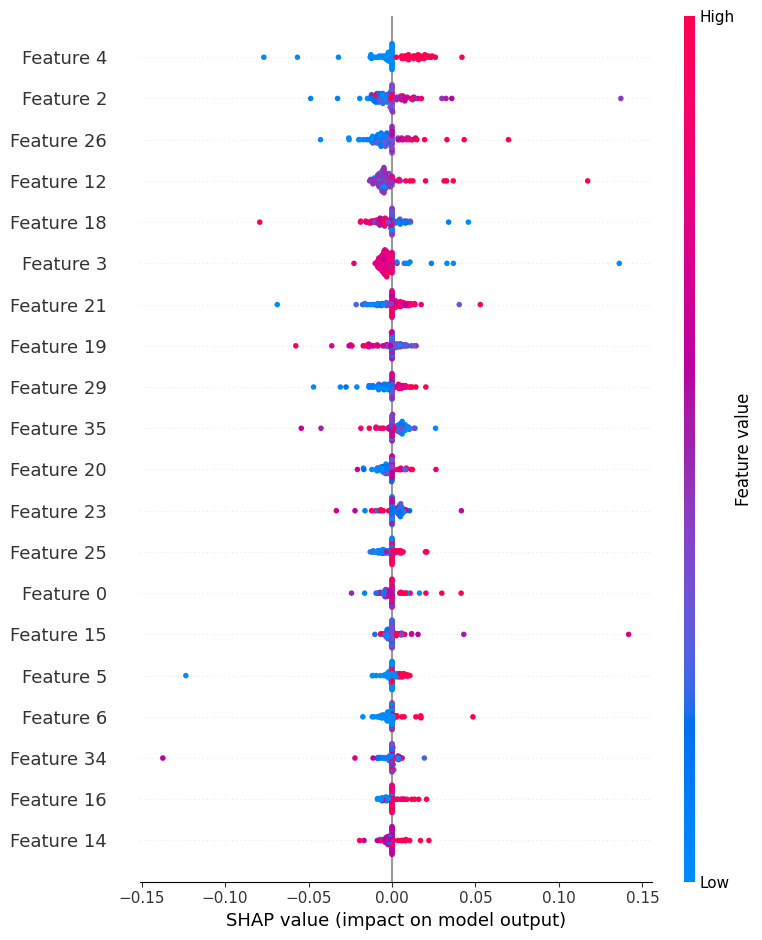

In [83]:
import numpy as np

shap_values_array = np.array(shap_values)
shap_values_reshaped = shap_values_array.squeeze()
shap.summary_plot(shap_values_reshaped, X_val)


In [84]:
pd.DataFrame(X_train)


,0,1,2,3,4,5,6,7,8,9,...,26,27,28,29,30,31,32,33,34,35
0,0.000876,0.000248,-0.265514,0.086392,1.0,0.0,0.0,0.0,-0.227,-2.727,...,-0.423353,-1.849246,0.434503,-0.425267,-0.734887,-1.677239,-0.951635,0.298713,-0.636047,-0.744437
1,0.000876,0.000248,-0.196815,0.086392,1.0,0.0,0.0,0.0,-0.227,-2.727,...,-0.493017,-0.737998,-0.627129,-0.511370,0.302486,0.984780,-1.005422,-0.519720,-0.651240,-0.744437
2,0.000876,0.000248,1.049229,0.086392,1.0,0.0,0.0,0.0,-0.227,-2.727,...,-0.758722,0.981181,-0.518710,0.592016,-0.791816,1.262326,-0.061335,-0.413208,-0.988747,-0.744437
3,0.000876,0.000248,-0.756565,0.086392,1.0,0.0,0.0,0.0,-0.227,-2.727,...,-0.577728,-0.158898,-0.078427,-0.852383,-0.477915,1.550335,-1.169957,-0.770272,-1.318330,-0.744437
4,0.000876,0.000248,0.118015,0.086392,1.0,0.0,0.0,0.0,-0.227,-2.727,...,0.819170,-0.406025,-0.941931,-0.847987,0.058956,0.800851,-0.429119,0.849486,-0.458990,-0.744437
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,0.000876,0.000248,-0.351327,0.086392,1.0,0.0,0.0,0.0,1.025,-2.165,...,-0.701255,1.590761,-0.747106,-0.249798,1.233116,0.907133,-1.167214,-0.058903,-0.510079,-0.744437
199996,0.949093,0.000248,0.203185,0.086392,0.0,1.0,0.0,0.0,-2.923,-2.165,...,0.333788,1.184649,0.792232,-0.283333,1.494041,-0.524101,-0.152541,-0.408793,-0.047465,-0.377417
199997,0.000876,0.000248,-0.773073,0.086392,1.0,0.0,0.0,0.0,-2.923,-2.165,...,-0.740605,0.943288,0.195099,0.086230,0.640897,1.547031,-0.082171,-0.436387,-0.617499,-0.744437
199998,0.000876,0.000248,0.655999,0.086392,1.0,0.0,0.0,0.0,-2.923,-2.165,...,-0.016761,-0.576542,-0.785631,0.413194,-0.059646,0.927508,-0.743886,-0.748197,-0.760696,-0.744437
